#  Notebook 02 — LSTM (From Scratch)

**Model**: 2-layer stacked LSTM  
**Implementation**: Pure PyTorch — no high-level wrappers  
**Input**: `(batch, 12, 207)` → **Output**: `(batch, 207)`

---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pickle

from utils.data_utils  import load_processed, make_loaders, inverse_transform
from utils.metrics     import compute_all_metrics, print_metrics
from utils.train_utils import EarlyStopping, full_train, predict_all, count_parameters

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 1. Load Processed Data

In [2]:
X_train, y_train, X_val, y_val, X_test, y_test, scaler = load_processed('../data/processed')

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')

train_loader, val_loader, test_loader = make_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test,
    batch_size_train=32, batch_size_eval=64
)

N_SENSORS = X_train.shape[2]   # 207
print(f'Number of sensors: {N_SENSORS}')

[load] Loaded processed data from ../data/processed\processed_data.pkl
X_train: (23978, 12, 207)  y_train: (23978, 207)
[loaders] Train:23978  Val:3415  Test:6843
Number of sensors: 207


## 2. Model Definition — LSTM From Scratch

In [3]:
class LSTMTrafficPredictor(nn.Module):
    """
    2-layer stacked LSTM for multi-sensor traffic speed prediction.

    Architecture:
        Input  (batch, T_in=12, N=207)
        → LSTM (hidden=64, layers=2, dropout=0.2)
        → Take last hidden state h_T
        → FC1 (64 → 128) + ReLU + Dropout(0.2)
        → FC2 (128 → N=207)
        Output (batch, 207)
    """

    def __init__(self, n_sensors=207, hidden_size=64, num_layers=2,
                 dropout=0.2, fc_hidden=128):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_sensors,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, fc_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_hidden, n_sensors),
        )

    def forward(self, x):
        # x : (batch, T, N)
        lstm_out, _ = self.lstm(x)          # (batch, T, hidden)
        last_h = lstm_out[:, -1, :]         # (batch, hidden)
        return self.fc(last_h)              # (batch, N)


model = LSTMTrafficPredictor(n_sensors=N_SENSORS).to(device)
print(f'Parameters: {count_parameters(model):,}')
print(model)

Parameters: 138,191
LSTMTrafficPredictor(
  (lstm): LSTM(207, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=207, bias=True)
  )
)


## 3. Training

In [4]:
criterion     = nn.MSELoss()
optimizer     = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler     = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
early_stop    = EarlyStopping(patience=10, path='../models/lstm_best.pth')

train_losses, val_losses = full_train(
    model, train_loader, val_loader,
    optimizer, criterion, scheduler, early_stop,
    device, max_epochs=100, model_name='LSTM'
)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Training LSTM on cuda
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Epoch    1/100 | train=0.046847 | val=0.024949
  ✓ Best model saved → ../models/lstm_best.pth  (val_loss=0.024949)
  ✓ Best model saved → ../models/lstm_best.pth  (val_loss=0.024762)
  ✓ Best model saved → ../models/lstm_best.pth  (val_loss=0.023590)
  ✓ Best model saved → ../models/lstm_best.pth  (val_loss=0.022278)
  Epoch    5/100 | train=0.020947 | val=0.021684
  ✓ Best model saved → ../models/lstm_best.pth  (val_loss=0.021684)
  ✓ Best model saved → ../models/lstm_best.pth  (val_loss=0.020186)
  ✓ Best model saved → ../models/lstm_best.pth  (val_loss=0.019130)
  EarlyStopping counter: 1/10
  ✓ Best model saved → ../models/lstm_best.pth  (val_loss=0.018834)
  Epoch   10/100 | train=0.018028 | val=0.018331
  ✓ Best model saved → ../models/lstm_best.pth  (val_loss=0.018331)
  ✓ Best model saved → ../models/lstm_best.pth  (val_loss=0.018282)
  EarlyStopping 

## 4. Training Curve

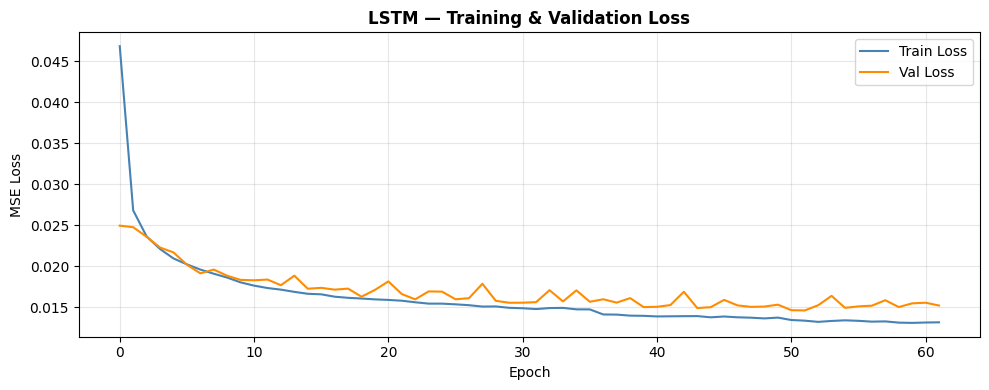

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train Loss', color='steelblue')
ax.plot(val_losses,   label='Val Loss',   color='darkorange')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('LSTM — Training & Validation Loss', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/lstm_training_curve.png', dpi=150)
plt.show()

## 5. Evaluation on Test Set

In [9]:
preds_norm, labels_norm = predict_all(model, test_loader, device)

# Inverse transform
preds  = inverse_transform(preds_norm, scaler)
labels = inverse_transform(labels_norm, scaler)

metrics = compute_all_metrics(preds, labels)
print_metrics(metrics, 'LSTM (From Scratch)')

# Save metrics
with open('../results/lstm_metrics.pkl', 'wb') as f:
    pickle.dump({'model': 'LSTM', 'metrics': metrics,
                 'train_losses': train_losses, 'val_losses': val_losses,
                 'params': count_parameters(model)}, f)
print('✅ Metrics saved → results/lstm_metrics.pkl')


  LSTM (From Scratch) — Evaluation Metrics
  MAE  : 5.0774 km/h
  RMSE : 9.9424 km/h
  MAPE : 10.28 %
  R²   : 0.8096

✅ Metrics saved → results/lstm_metrics.pkl


## 6. Prediction Visualization

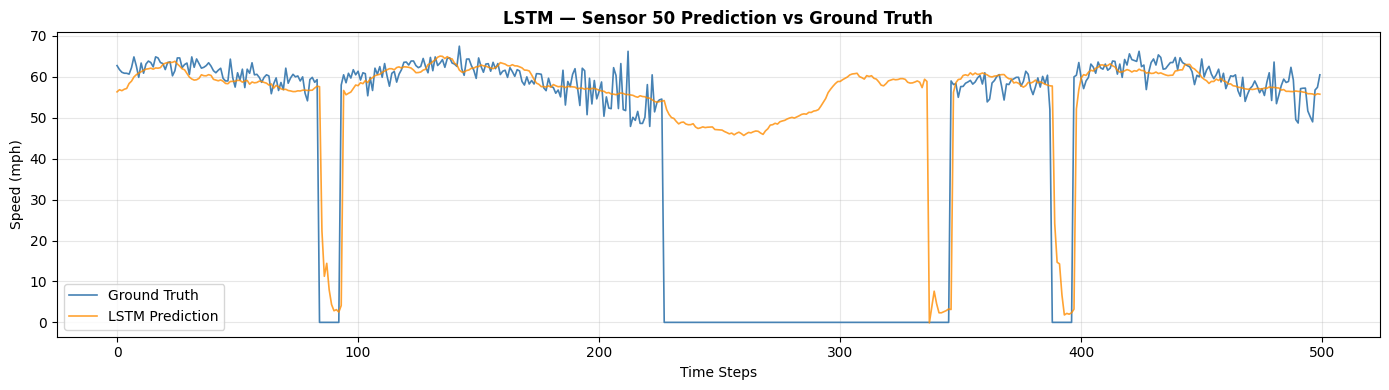

In [10]:
# Show predictions vs ground truth for a single sensor
sensor_idx = 50
n_show     = 500

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(labels[:n_show, sensor_idx], label='Ground Truth', color='steelblue', lw=1.2)
ax.plot(preds[:n_show,  sensor_idx], label='LSTM Prediction', color='darkorange', lw=1.2, alpha=0.8)
ax.set_title(f'LSTM — Sensor {sensor_idx} Prediction vs Ground Truth', fontweight='bold')
ax.set_xlabel('Time Steps')
ax.set_ylabel('Speed (mph)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/lstm_prediction_viz.png', dpi=150)
plt.show()